#### Extracting Pipeline Components

In [1]:
import joblib

pipeline = joblib.load("../artifacts/xgboost_fraud_detector.joblib")

In [2]:
preprocessor = pipeline.named_steps["preprocessor"]
xgb_model = pipeline.named_steps["model"]

In [3]:
print(preprocessor)
print(xgb_model)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['type']),
                                ('num', 'passthrough',
                                 ['step', 'amount', 'oldbalance_org',
                                  'newbalance_orig', 'oldbalance_dest',
                                  'newbalance_dest', 'diff_new_old_balance',
                                  'diff_new_old_dest'])])
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_de

#### Preparing Sample Data

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/fraud_0.1origbase.csv")

In [5]:
df.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
382489,231,CASH_IN,277562.61,C1076279394,30847.0,308409.61,C530350995,0.0,0.0,0,0


In [6]:
df["diff_new_old_balance"] = (
    df["newbalanceOrig"] - df["oldbalanceOrg"]
)

df["diff_new_old_dest"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

#### Renaming Columns

In [7]:
import inflection
df.columns = [inflection.underscore(col) for col in df.columns]

#### Creating Input Matrix

In [8]:
features = [
    'type',
    'step',
    'amount',
    'oldbalance_org',
    'newbalance_orig',
    'oldbalance_dest',
    'newbalance_dest',
    'diff_new_old_balance',
    'diff_new_old_dest'
]

X = df[features].sample(1000, random_state=42)

#### Transforming Data

In [9]:
X_transformed = preprocessor.transform(X)

In [10]:
X_transformed.shape

(1000, 13)

In [11]:
feature_names = preprocessor.get_feature_names_out()

In [12]:
feature_names

array(['cat__type_CASH_IN', 'cat__type_CASH_OUT', 'cat__type_DEBIT',
       'cat__type_PAYMENT', 'cat__type_TRANSFER', 'num__step',
       'num__amount', 'num__oldbalance_org', 'num__newbalance_orig',
       'num__oldbalance_dest', 'num__newbalance_dest',
       'num__diff_new_old_balance', 'num__diff_new_old_dest'],
      dtype=object)

#### SHAP Explainer

In [13]:
import shap
explainer = shap.TreeExplainer(xgb_model)

In [14]:
shap_values = explainer.shap_values(X_transformed)

In [15]:
shap_values.shape

(1000, 13)

#### Plots

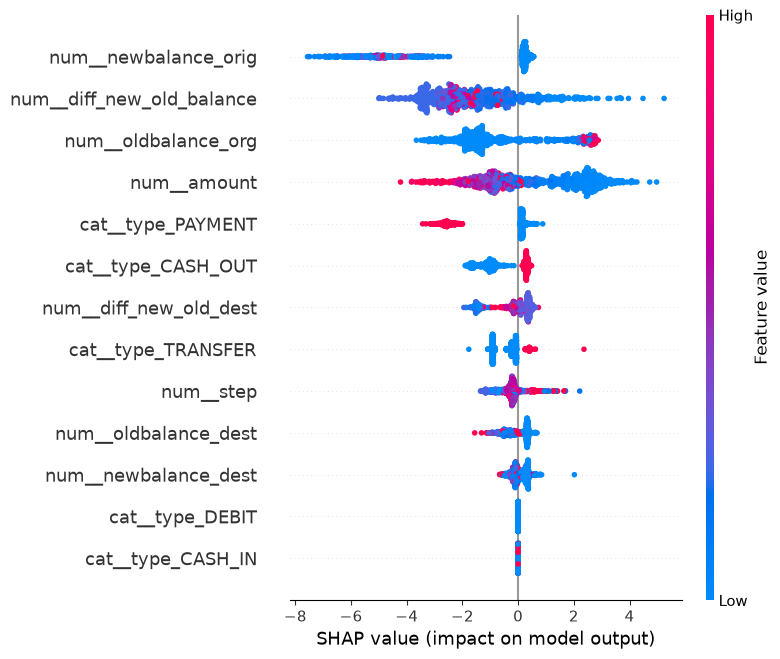

In [17]:
# import matplotlib.pyplot as plt

# shap.summary_plot(
#     shap_values,
#     X_transformed,
#     feature_names=feature_names
# )

# plt.tight_layout()
# plt.savefig("../reports/shap_summary.png")
# plt.show()
import matplotlib.pyplot as plt
import shap

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=False
)

plt.savefig("../reports/figures/shap_summary.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

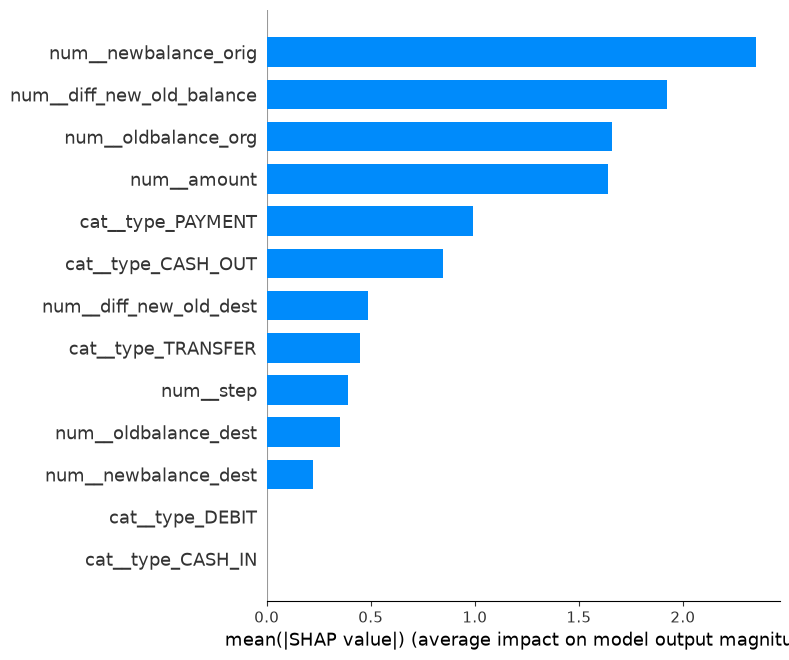

In [31]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("../reports/shap_bar.png")
plt.show()